In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import shap
from sklearn.inspection import PartialDependenceDisplay

In [ ]:
df = pd.read_csv("/content/insurance.csv")

df["log_charges"] = np.log(df["charges"])
df["age2"]        = df["age"] ** 2
df["bmi2"]        = df["bmi"] ** 2
df["obese"]       = (df["bmi"] >= 30).astype(int)
df["is_smoker"]   = (df["smoker"] == "yes").astype(int)
df["bmi_smoker"]  = df["bmi"] * df["is_smoker"]

FEATURES = ["age", "age2", "bmi", "bmi2", "obese", "is_smoker", "bmi_smoker"]
# FEATURES = ['age', 'age2', 'sex', 'bmi', 'children', 'smoker', 'smoker_bmi', 'smoker_age', 'smoker_obese', 'obese', 'region']
final_df = pd.read_csv('/content/final_df.csv')
final_df = final_df.drop_duplicates().reset_index(drop=True)
display(final_df)
# X = final_df[FEATURES].values
# y = final_df["charges_log"].values
X = df[FEATURES].values
y = df["log_charges"].values

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,...,obese,smoker_age,smoker_bmi,smoker_obese,charges_log,bmi_age_interact,risk_score,age_scaled,bmi_scaled,charges_scaled
0,0,19,0,27.900,0,1,3,16884.92400,2,0,...,0,19,27.90,0,9.734236,530.100,6,-0.833333,-0.297265,0.629546
1,1,18,1,33.770,1,0,2,1725.55230,3,0,...,1,0,0.00,0,7.453882,607.860,4,-0.875000,0.400713,-0.643134
2,2,28,1,33.000,3,0,2,4449.46200,3,0,...,1,0,0.00,0,8.400763,924.000,5,-0.458333,0.309156,-0.414453
3,3,33,1,22.705,0,0,1,21984.47061,1,1,...,0,0,0.00,0,9.998137,749.265,4,-0.250000,-0.914982,1.057671
4,4,32,1,28.880,0,0,1,3866.85520,2,1,...,0,0,0.00,0,8.260455,924.160,5,-0.291667,-0.180737,-0.463364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,1332,50,1,30.970,3,0,1,10600.54830,3,2,...,1,0,0.00,0,9.268755,1548.500,8,0.458333,0.067776,0.101952
1333,1333,18,0,31.920,0,0,0,2205.98080,3,0,...,1,0,0.00,0,7.699381,574.560,4,-0.875000,0.180737,-0.602800
1334,1334,18,0,36.850,0,0,2,1629.83350,3,0,...,1,0,0.00,0,7.396847,663.300,4,-0.875000,0.766944,-0.651170
1335,1335,21,0,25.800,0,0,3,2007.94500,2,0,...,0,0,0.00,0,7.605365,541.800,4,-0.750000,-0.546968,-0.619426


In [ ]:
# OLS on log charges
ols = LinearRegression().fit(X, y)
df["ols_pred"] = np.exp(ols.predict(X))
ols_r2 = r2_score(df["charges"], df["ols_pred"])

print("=" * 50)
print("OLS on log(charges)")
print("=" * 50)
for name, coef in zip(FEATURES, ols.coef_):
    print(f"  {name:<14} {coef:+.4f}")
print(f"  intercept      {ols.intercept_:+.4f}")
print(f"\n  R² ($ scale):  {ols_r2:.3f}")

OLS on log(charges)
  age            +0.0699
  age2           -0.0004
  bmi            +0.0308
  bmi2           -0.0006
  obese          +0.0882
  is_smoker      +0.1845
  bmi_smoker     +0.0444
  intercept      +6.3543

  R² ($ scale):  0.586


Passable. Shows broad relationships, but too much is unexplained and values may be less accurate.

In [ ]:
# Quantile Regression (q = 0.10, 0.50, 0.90)
# Deleted. Low quantiles have no smokers so output is meaningless.


Quantile Regression on log(charges)

  q = 0.1  (R²=0.475)
    age            +0.1315
    age2           -0.0010
    bmi            -0.0093
    bmi2           +0.0001
    obese          +0.0315
    is_smoker      -0.1453
    bmi_smoker     +0.0437

  q = 0.5  (R²=0.493)
    age            +0.0751
    age2           -0.0004
    bmi            +0.0078
    bmi2           -0.0001
    obese          +0.0266
    is_smoker      +0.1904
    bmi_smoker     +0.0451

  q = 0.9  (R²=0.682)
    age            -0.0146
    age2           +0.0004
    bmi            +0.0482
    bmi2           -0.0008
    obese          +0.3583
    is_smoker      +0.1663
    bmi_smoker     +0.0301


Useless.

In [ ]:
# Random Forest (orig)
rf = RandomForestRegressor(n_estimators=75, random_state=42)
rf.fit(X, y)
df["rf_pred"] = np.exp(rf.predict(X))
rf_r2 = r2_score(df["charges"], df["rf_pred"])

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("\n" + "=" * 50)
print("Random Forest")
print("=" * 50)
print("\n  Feature importances:")
for feat, imp in importances.items():
    print(f"    {feat:<14} {imp:.3f}")
print(f"\n  R² ($ scale):  {rf_r2:.3f}")


Random Forest

  Feature importances:
    bmi_smoker     0.396
    age2           0.199
    age            0.184
    bmi            0.079
    bmi2           0.077
    is_smoker      0.060
    obese          0.004

  R² ($ scale):  0.958


In [ ]:
# Random Forest (New)
rf = RandomForestRegressor(n_estimators=75, random_state=42)
rf.fit(X, y)
final_df["rf_pred"] = np.exp(rf.predict(X))
rf_r2 = r2_score(final_df["charges"], final_df["rf_pred"])

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("\n" + "=" * 50)
print("Random Forest")
print("=" * 50)
print("\n  Feature importances:")
for feat, imp in importances.items():
    print(f"    {feat:<14} {imp:.3f}")
print(f"\n  R² ($ scale):  {rf_r2:.3f}")


Random Forest

  Feature importances:
    smoker_bmi     0.347
    age2           0.196
    age            0.176
    bmi            0.081
    smoker_age     0.064
    smoker         0.048
    children       0.048
    region         0.022
    sex            0.011
    obese          0.005
    smoker_obese   0.002

  R² ($ scale):  0.963


Better. Maybe this can be useful in a little bit. But let's validate.

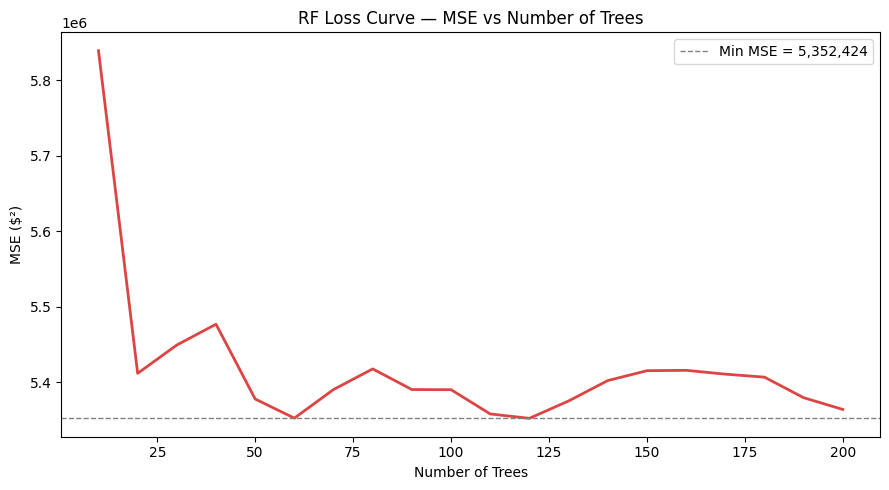

In [ ]:
from sklearn.metrics import mean_squared_error

n_estimators_range = range(10, 201, 10)
mse_scores = []

rf_mse = RandomForestRegressor(n_estimators=75, random_state=42, warm_start=True)

for n in n_estimators_range:
    rf_mse.set_params(n_estimators=n)
    rf_mse.fit(X, y)
    preds = np.exp(rf_mse.predict(X))
    mse_scores.append(mean_squared_error(np.exp(y), preds))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_estimators_range, mse_scores, color="#DD4444", lw=2)
ax.set(title="RF Loss Curve — MSE vs Number of Trees",
       xlabel="Number of Trees", ylabel="MSE ($²)")
ax.axhline(min(mse_scores), color="gray", linestyle="--", lw=1,
           label=f"Min MSE = {min(mse_scores):,.0f}")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2")

print(f"CV R² scores:  {cv_scores.round(3)}")
print(f"Mean CV R²:    {cv_scores.mean():.3f}")
print(f"Std CV R²:     {cv_scores.std():.3f}")

CV R² scores:  [0.851 0.702 0.865 0.821 0.794]
Mean CV R²:    0.806
Std CV R²:     0.058


Ah, that's a significant decrease. Much of the future analysis should still hold up. However, this explains the variability and instability in a few of the later graphs.

In [ ]:
ols_cv = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")

print(f"OLS CV R² scores: {ols_cv.round(3)}")
print(f"Mean CV R²:       {ols_cv.mean():.3f}")
print(f"Std CV R²:        {ols_cv.std():.3f}")

OLS CV R² scores: [0.885 0.728 0.899 0.829 0.8  ]
Mean CV R²:       0.828
Std CV R²:        0.062


So OLS explains some of the data better than RF. But OLS has been done quite a bit in earlier presentations, so let's keep at RF to see if we can find anything new.

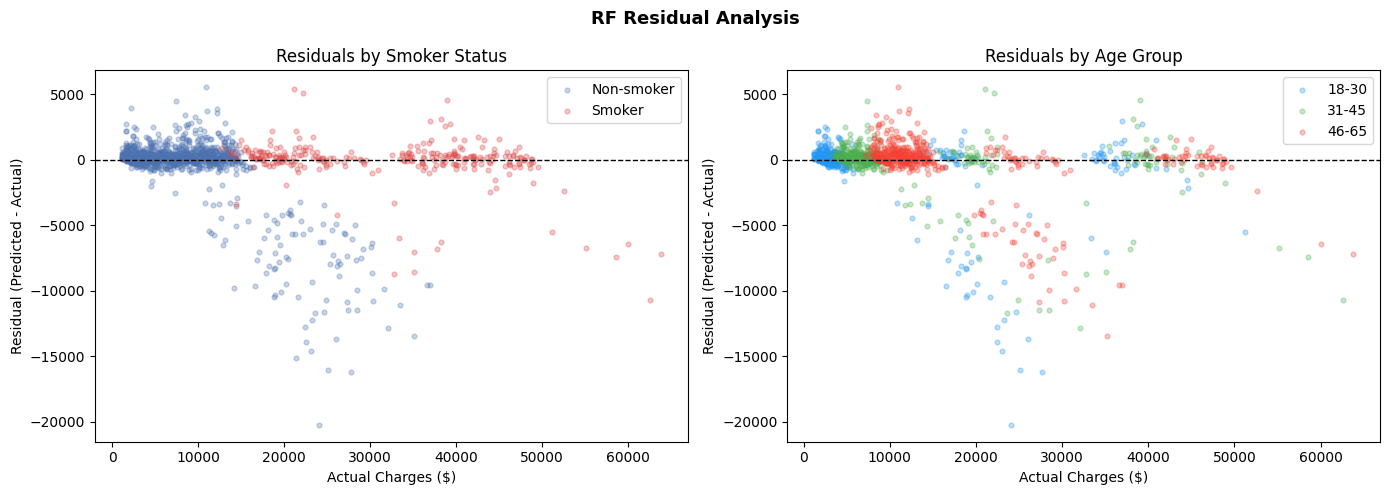

In [ ]:
# Residual Analysis by Subgroup
df["residual"] = df["rf_pred"] - df["charges"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals by smoker status
for val, label, color in [(0, "Non-smoker", "#4C72B0"), (1, "Smoker", "#DD4444")]:
    mask = df["is_smoker"] == val
    axes[0].scatter(df.loc[mask, "charges"], df.loc[mask, "residual"],
                    alpha=0.3, s=12, color=color, label=label)

axes[0].axhline(0, color="black", lw=1, linestyle="--")
axes[0].set(title="Residuals by Smoker Status",
            xlabel="Actual Charges ($)", ylabel="Residual (Predicted - Actual)")
axes[0].legend()

# Plot 2: Residuals by age group
df["age_group"] = pd.cut(df["age"], bins=[18, 30, 45, 65],
                          labels=["18-30", "31-45", "46-65"])

age_colors = {"18-30": "#2196F3", "31-45": "#4CAF50", "46-65": "#F44336"}
for group, color in age_colors.items():
    mask = df["age_group"] == group
    axes[1].scatter(df.loc[mask, "charges"], df.loc[mask, "residual"],
                    alpha=0.3, s=12, color=color, label=group)

axes[1].axhline(0, color="black", lw=1, linestyle="--")
axes[1].set(title="Residuals by Age Group",
            xlabel="Actual Charges ($)", ylabel="Residual (Predicted - Actual)")
axes[1].legend()

plt.suptitle("RF Residual Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In an ideal world the points would sit around the dashed line. But quite a few sit under it, which lines up with RF undershooting. Usually applies to the most expensive cases being underestimated.

RF naturally takes countless samples, so the extremes are often unfairly negated. Will continue with RF but later will try some other things...

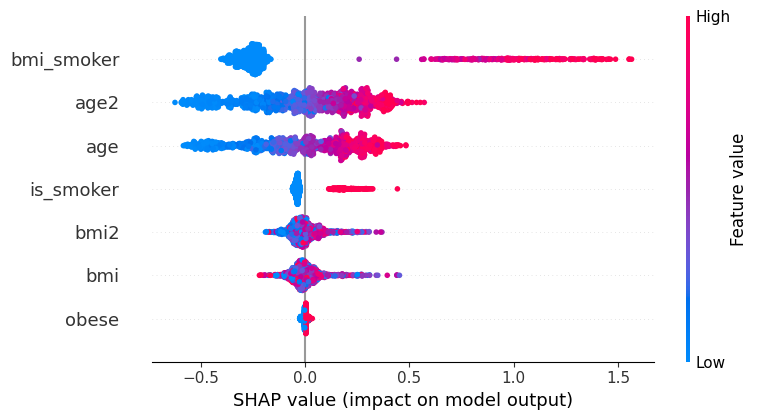

In [ ]:
# Fit RF
rf = RandomForestRegressor(n_estimators=75, random_state=42)
rf.fit(X, y)

# SHAP values
X_named = pd.DataFrame(X, columns=FEATURES)
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_named)
shap.summary_plot(shap_values, X_named)

Very informative. Code took too long to run to replace features, so just printed. Shows extreme correlations in the way we predicted. Ex: bmi_smoker shows that nonsmokers decrease cost, but smokers increase cost with high bmi. Blue applies for all non smokers no matter what, red applies to smokers with high bmi.

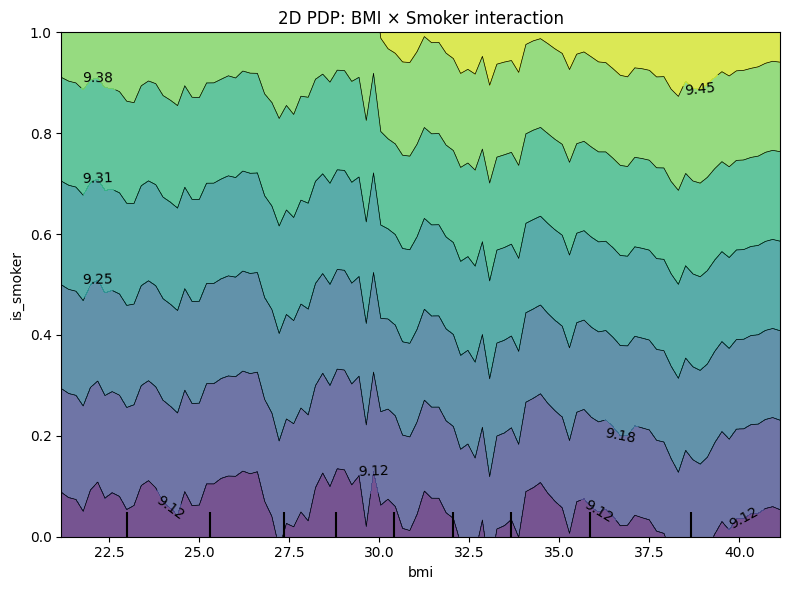

In [ ]:
# 2D Partial Dependence Plot (BMI x smoker)
# Deleted. Too hard to read/interpret.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


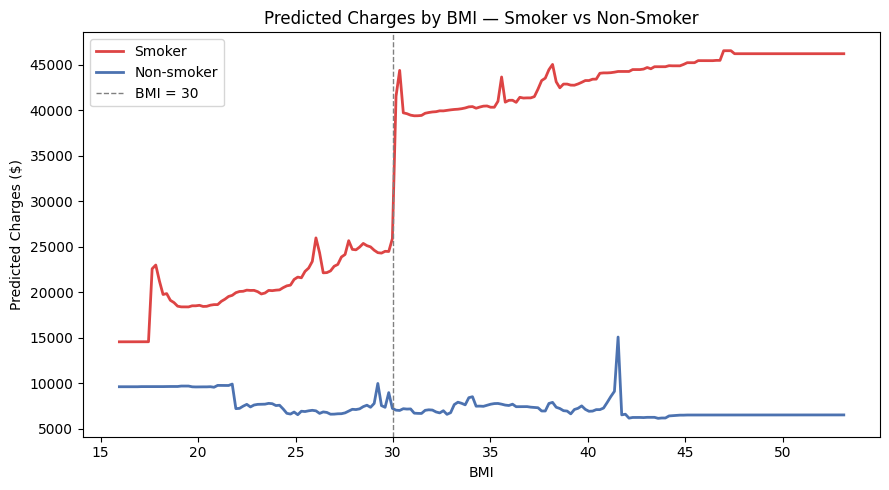

In [ ]:
# Synthetic DataFrames: smoker vs non-smoker
# BMI range across observed values
bmi_range = np.linspace(df["bmi"].min(), df["bmi"].max(), 200)

def make_pred_df(bmi_vals, smoker_val):
    d = pd.DataFrame({
        "age":        df["age"].mean(),
        "age2":       df["age2"].mean(),
        "bmi":        bmi_vals,
        "bmi2":       bmi_vals ** 2,
        "obese":      (bmi_vals >= 30).astype(int),
        "is_smoker":  smoker_val,
        "bmi_smoker": bmi_vals * smoker_val
    })
    return d

smoker_preds    = np.exp(rf.predict(make_pred_df(bmi_range, 1)))
nonsmoker_preds = np.exp(rf.predict(make_pred_df(bmi_range, 0)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(bmi_range, smoker_preds,    color="#DD4444", lw=2, label="Smoker")
ax.plot(bmi_range, nonsmoker_preds, color="#4C72B0", lw=2, label="Non-smoker")
ax.axvline(30, color="gray", linestyle="--", lw=1, label="BMI = 30")
ax.set(title="Predicted Charges by BMI — Smoker vs Non-Smoker",
       xlabel="BMI", ylabel="Predicted Charges ($)")
ax.legend()
plt.tight_layout()
plt.show()

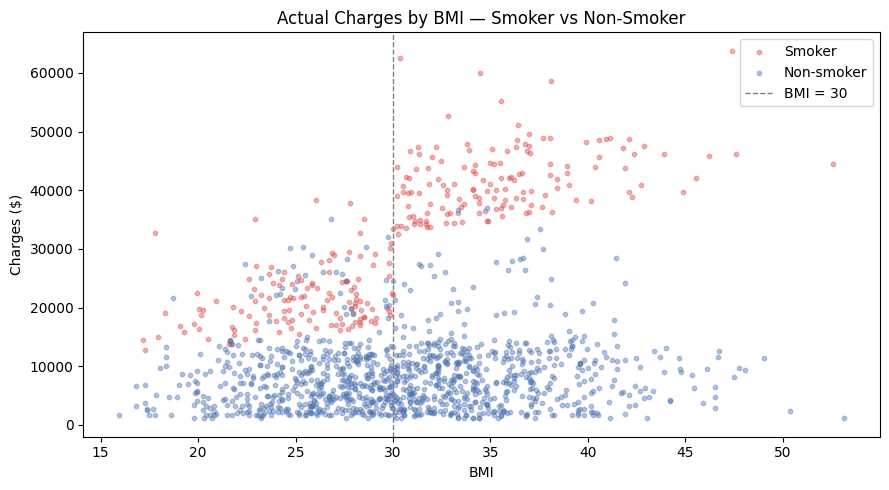

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for val, color, label in [(1, "#DD4444", "Smoker"),
                           (0, "#4C72B0", "Non-smoker")]:
    mask = df["is_smoker"] == val
    ax.scatter(df.loc[mask, "bmi"], df.loc[mask, "charges"],
               color=color, alpha=0.4, s=10, label=label)

ax.axvline(30, color="gray", linestyle="--", lw=1, label="BMI = 30")
ax.set(title="Actual Charges by BMI — Smoker vs Non-Smoker",
       xlabel="BMI", ylabel="Charges ($)")
ax.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


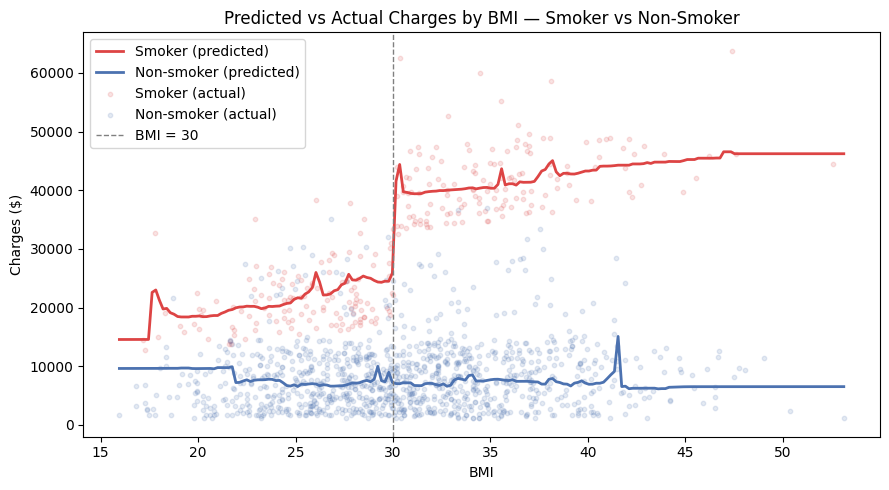

In [ ]:
bmi_range = np.linspace(df["bmi"].min(), df["bmi"].max(), 200)

def make_pred_df(bmi_vals, smoker_val):
    d = pd.DataFrame({
        "age":        df["age"].mean(),
        "age2":       df["age2"].mean(),
        "bmi":        bmi_vals,
        "bmi2":       bmi_vals ** 2,
        "obese":      (bmi_vals >= 30).astype(int),
        "is_smoker":  smoker_val,
        "bmi_smoker": bmi_vals * smoker_val
    })
    return d

smoker_preds    = np.exp(rf.predict(make_pred_df(bmi_range, 1)))
nonsmoker_preds = np.exp(rf.predict(make_pred_df(bmi_range, 0)))

fig, ax = plt.subplots(figsize=(9, 5))

# Predicted lines
ax.plot(bmi_range, smoker_preds,    color="#DD4444", lw=2, label="Smoker (predicted)")
ax.plot(bmi_range, nonsmoker_preds, color="#4C72B0", lw=2, label="Non-smoker (predicted)")

# Actual scatter points — transparent versions of respective colors
for val, color, label in [(1, "#DD4444", "Smoker (actual)"),
                           (0, "#4C72B0", "Non-smoker (actual)")]:
    mask = df["is_smoker"] == val
    ax.scatter(df.loc[mask, "bmi"], df.loc[mask, "charges"],
               color=color, alpha=0.15, s=10, label=label)

ax.axvline(30, color="gray", linestyle="--", lw=1, label="BMI = 30")
ax.set(title="Predicted vs Actual Charges by BMI — Smoker vs Non-Smoker",
       xlabel="BMI", ylabel="Charges ($)")
ax.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


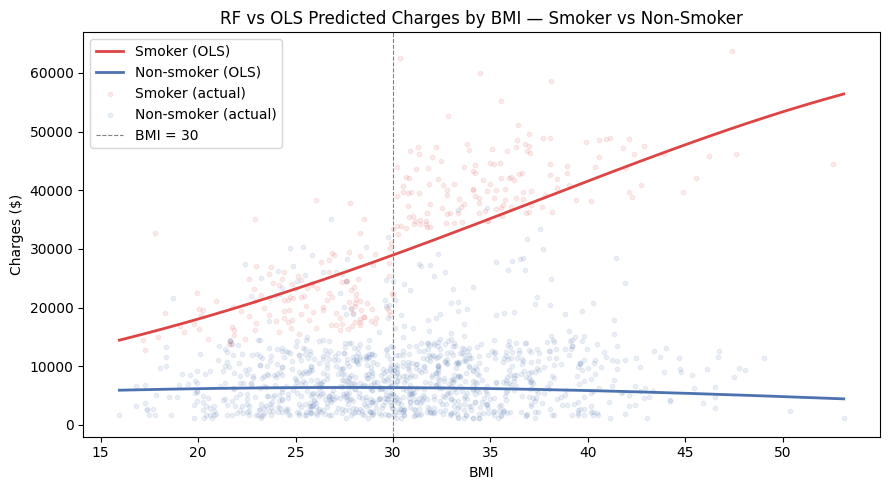

In [ ]:
bmi_range = np.linspace(df["bmi"].min(), df["bmi"].max(), 200)

def make_pred_df(bmi_vals, smoker_val):
    d = pd.DataFrame({
        "age":        df["age"].mean(),
        "age2":       df["age2"].mean(),
        "bmi":        bmi_vals,
        "bmi2":       bmi_vals ** 2,
        "obese":      0,
        "is_smoker":  smoker_val,
        "bmi_smoker": bmi_vals * smoker_val
    })
    return d

smoker_preds    = np.exp(rf.predict(make_pred_df(bmi_range, 1)))
nonsmoker_preds = np.exp(rf.predict(make_pred_df(bmi_range, 0)))

# OLS predictions on same grid
ols_smoker_preds    = np.exp(ols.predict(make_pred_df(bmi_range, 1)))
ols_nonsmoker_preds = np.exp(ols.predict(make_pred_df(bmi_range, 0)))

fig, ax = plt.subplots(figsize=(9, 5))

# OLS predicted lines — dashed, same colors
ax.plot(bmi_range, ols_smoker_preds,    color="#DD4444", lw=2, linestyle="-", label="Smoker (OLS)")
ax.plot(bmi_range, ols_nonsmoker_preds, color="#4C72B0", lw=2, linestyle="-", label="Non-smoker (OLS)")

# Actual scatter points
for val, color, label in [(1, "#DD4444", "Smoker (actual)"),
                           (0, "#4C72B0", "Non-smoker (actual)")]:
    mask = df["is_smoker"] == val
    ax.scatter(df.loc[mask, "bmi"], df.loc[mask, "charges"],
               color=color, alpha=0.1, s=10, label=label)

ax.axvline(30, color="gray", linestyle="--", lw=0.8, label="BMI = 30")
ax.set(title="RF vs OLS Predicted Charges by BMI — Smoker vs Non-Smoker",
       xlabel="BMI", ylabel="Charges ($)")
ax.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


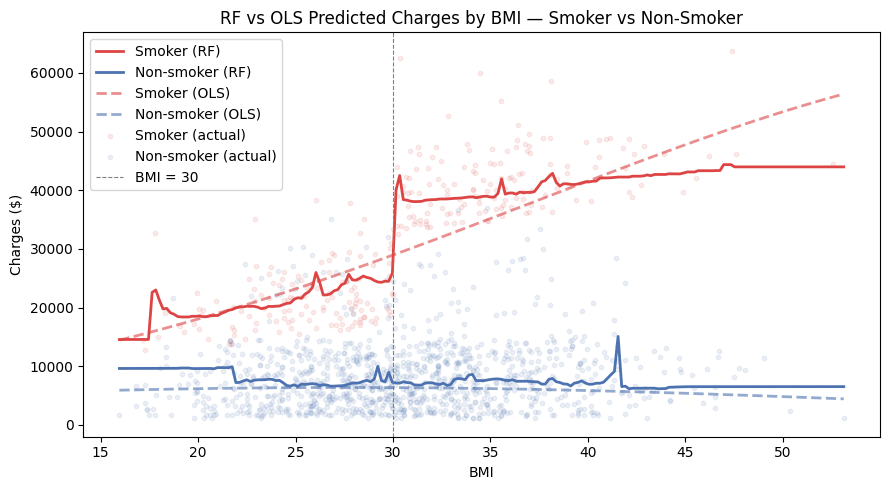

In [ ]:
bmi_range = np.linspace(df["bmi"].min(), df["bmi"].max(), 200)

def make_pred_df(bmi_vals, smoker_val):
    d = pd.DataFrame({
        "age":        df["age"].mean(),
        "age2":       df["age2"].mean(),
        "bmi":        bmi_vals,
        "bmi2":       bmi_vals ** 2,
        "obese":      0,
        "is_smoker":  smoker_val,
        "bmi_smoker": bmi_vals * smoker_val
    })
    return d

smoker_preds    = np.exp(rf.predict(make_pred_df(bmi_range, 1)))
nonsmoker_preds = np.exp(rf.predict(make_pred_df(bmi_range, 0)))

# OLS predictions on same grid
ols_smoker_preds    = np.exp(ols.predict(make_pred_df(bmi_range, 1)))
ols_nonsmoker_preds = np.exp(ols.predict(make_pred_df(bmi_range, 0)))

fig, ax = plt.subplots(figsize=(9, 5))

# RF predicted lines
ax.plot(bmi_range, smoker_preds,    color="#DD4444", lw=2, label="Smoker (RF)")
ax.plot(bmi_range, nonsmoker_preds, color="#4C72B0", lw=2, label="Non-smoker (RF)")

# OLS predicted lines — dashed, same colors
ax.plot(bmi_range, ols_smoker_preds,    color="#DD4444", lw=2, linestyle="--", label="Smoker (OLS)", alpha=0.6)
ax.plot(bmi_range, ols_nonsmoker_preds, color="#4C72B0", lw=2, linestyle="--", label="Non-smoker (OLS)", alpha=0.6)

# Actual scatter points
for val, color, label in [(1, "#DD4444", "Smoker (actual)"),
                           (0, "#4C72B0", "Non-smoker (actual)")]:
    mask = df["is_smoker"] == val
    ax.scatter(df.loc[mask, "bmi"], df.loc[mask, "charges"],
               color=color, alpha=0.1, s=10, label=label)

ax.axvline(30, color="gray", linestyle="--", lw=0.8, label="BMI = 30")
ax.set(title="RF vs OLS Predicted Charges by BMI — Smoker vs Non-Smoker",
       xlabel="BMI", ylabel="Charges ($)")
ax.legend()
plt.tight_layout()
plt.show()

This is very very informative. we used RF to separate, and we see a negliglbe effect on cost regarding bmi for non-smokers. For smokers, there is a continuous relationship for most of the plot EXCEPT for a jump at 30. Hybrid categorical and continuous, in a way.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


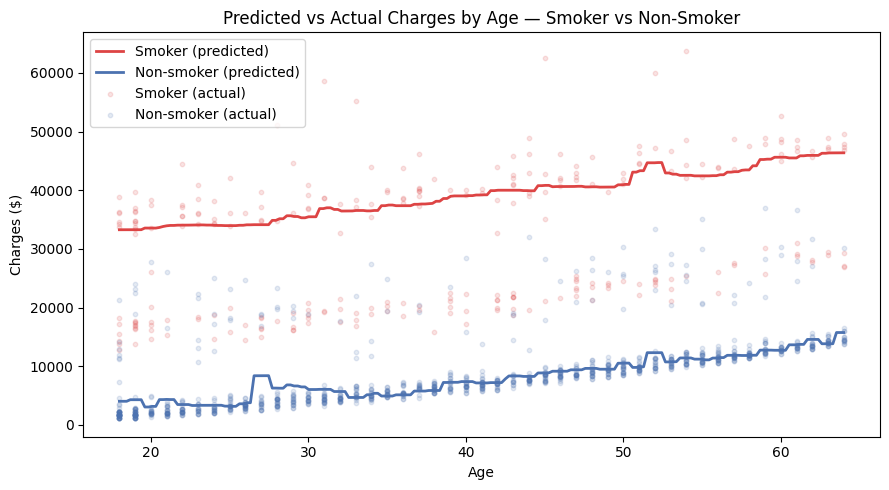

In [ ]:
# Age vs Smoker
age_range = np.linspace(df["age"].min(), df["age"].max(), 200)
mean_bmi  = df["bmi"].mean()

def make_age_pred_df(age_vals, smoker_val):
    return pd.DataFrame({
        "age":        age_vals,
        "age2":       age_vals ** 2,
        "bmi":        mean_bmi,
        "bmi2":       mean_bmi ** 2,
        "obese":      int(mean_bmi >= 30),
        "is_smoker":  smoker_val,
        "bmi_smoker": mean_bmi * smoker_val
    })

smoker_age_preds    = np.exp(rf.predict(make_age_pred_df(age_range, 1)))
nonsmoker_age_preds = np.exp(rf.predict(make_age_pred_df(age_range, 0)))

fig, ax = plt.subplots(figsize=(9, 5))

# Predicted lines
ax.plot(age_range, smoker_age_preds,    color="#DD4444", lw=2, label="Smoker (predicted)")
ax.plot(age_range, nonsmoker_age_preds, color="#4C72B0", lw=2, label="Non-smoker (predicted)")

# Actual scatter points
for val, color, label in [(1, "#DD4444", "Smoker (actual)"),
                           (0, "#4C72B0", "Non-smoker (actual)")]:
    mask = df["is_smoker"] == val
    ax.scatter(df.loc[mask, "age"], df.loc[mask, "charges"],
               color=color, alpha=0.15, s=10, label=label)

ax.set(title="Predicted vs Actual Charges by Age — Smoker vs Non-Smoker",
       xlabel="Age", ylabel="Charges ($)")
ax.legend()
plt.tight_layout()
plt.show()

Nothing we don't already know. Continuous for each smoker status.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


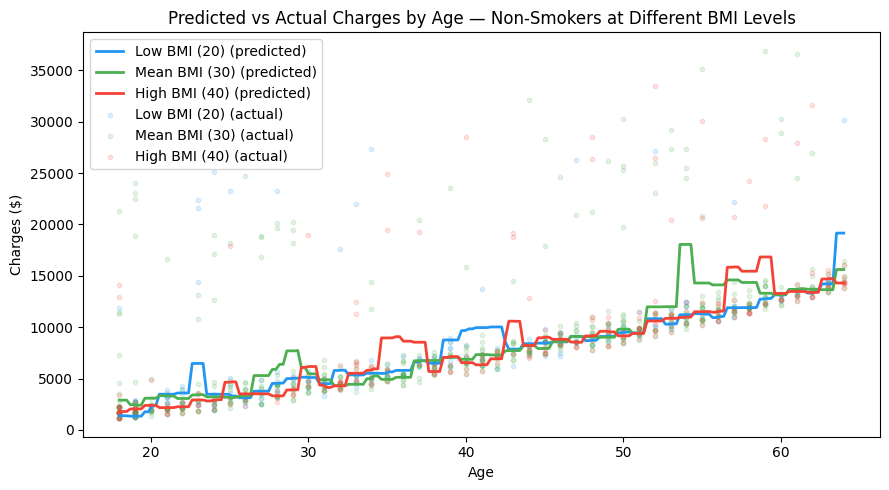

In [ ]:
# Age vs BMI (non-smokers only, three BMI groups)
bmi_groups = {"Low BMI (20)": 20, "Mean BMI (30)": 30, "High BMI (40)": 40}
bmi_colors = {"Low BMI (20)": "#2196F3", "Mean BMI (30)": "#4CAF50", "High BMI (40)": "#F44336"}

# BMI bins to approximate low/mean/high actual datapoints
bmi_bins = {"Low BMI (20)": (0, 25), "Mean BMI (30)": (25, 35), "High BMI (40)": (35, 99)}

def make_age_bmi_pred_df(age_vals, bmi_val):
    return pd.DataFrame({
        "age":        age_vals,
        "age2":       age_vals ** 2,
        "bmi":        bmi_val,
        "bmi2":       bmi_val ** 2,
        "obese":      int(bmi_val >= 30),
        "is_smoker":  0,
        "bmi_smoker": 0
    })

fig, ax = plt.subplots(figsize=(9, 5))

# Predicted lines
for label, bmi_val in bmi_groups.items():
    preds = np.exp(rf.predict(make_age_bmi_pred_df(age_range, bmi_val)))
    ax.plot(age_range, preds, color=bmi_colors[label], lw=2, label=f"{label} (predicted)")

# Actual scatter points — non-smokers only, binned by BMI range
for label, (bmi_lo, bmi_hi) in bmi_bins.items():
    mask = (df["is_smoker"] == 0) & (df["bmi"] >= bmi_lo) & (df["bmi"] < bmi_hi)
    ax.scatter(df.loc[mask, "age"], df.loc[mask, "charges"],
               color=bmi_colors[label], alpha=0.15, s=10, label=f"{label} (actual)")

ax.set(title="Predicted vs Actual Charges by Age — Non-Smokers at Different BMI Levels",
       xlabel="Age", ylabel="Charges ($)")
ax.legend()
plt.tight_layout()
plt.show()

For non smokers, age and bmi aren't really correlated. peaks arent super jarring, as we are unable to accurately evaluate outliers.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


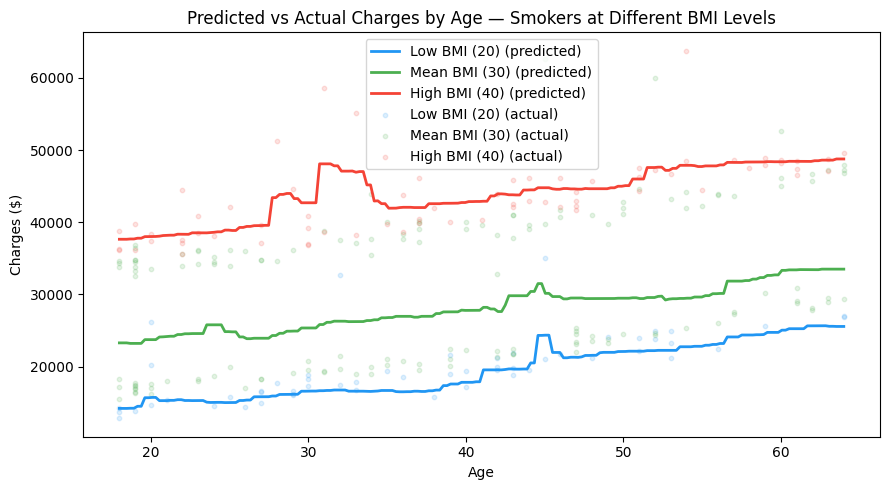

In [ ]:
def make_age_bmi_pred_df_smoker(age_vals, bmi_val):
    return pd.DataFrame({
        "age":        age_vals,
        "age2":       age_vals ** 2,
        "bmi":        bmi_val,
        "bmi2":       bmi_val ** 2,
        "obese":      int(bmi_val >= 30),
        "is_smoker":  1,
        "bmi_smoker": bmi_val * 1
    })

fig, ax = plt.subplots(figsize=(9, 5))

# Predicted lines
for label, bmi_val in bmi_groups.items():
    preds = np.exp(rf.predict(make_age_bmi_pred_df_smoker(age_range, bmi_val)))
    ax.plot(age_range, preds, color=bmi_colors[label], lw=2, label=f"{label} (predicted)")

# Actual scatter points — smokers only, binned by BMI range
for label, (bmi_lo, bmi_hi) in bmi_bins.items():
    mask = (df["is_smoker"] == 1) & (df["bmi"] >= bmi_lo) & (df["bmi"] < bmi_hi)
    ax.scatter(df.loc[mask, "age"], df.loc[mask, "charges"],
               color=bmi_colors[label], alpha=0.15, s=10, label=f"{label} (actual)")

ax.set(title="Predicted vs Actual Charges by Age — Smokers at Different BMI Levels",
       xlabel="Age", ylabel="Charges ($)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
mask = (df["is_smoker"] == 1) & (df["bmi"] >= 40) & (df["age"].between(25, 40))
print(df[mask].shape[0])

4


Shows again that age increases at the same continuous rate for all bmi levels. BMI is affected obviously, but we already know that.

Model                      Mean R²     Std
Random Forest                0.736   0.059
Gradient Boosting            0.754   0.072

RF fold scores:  [0.789 0.636 0.799 0.745 0.712]
GB fold scores:  [0.812 0.632 0.835 0.761 0.729]


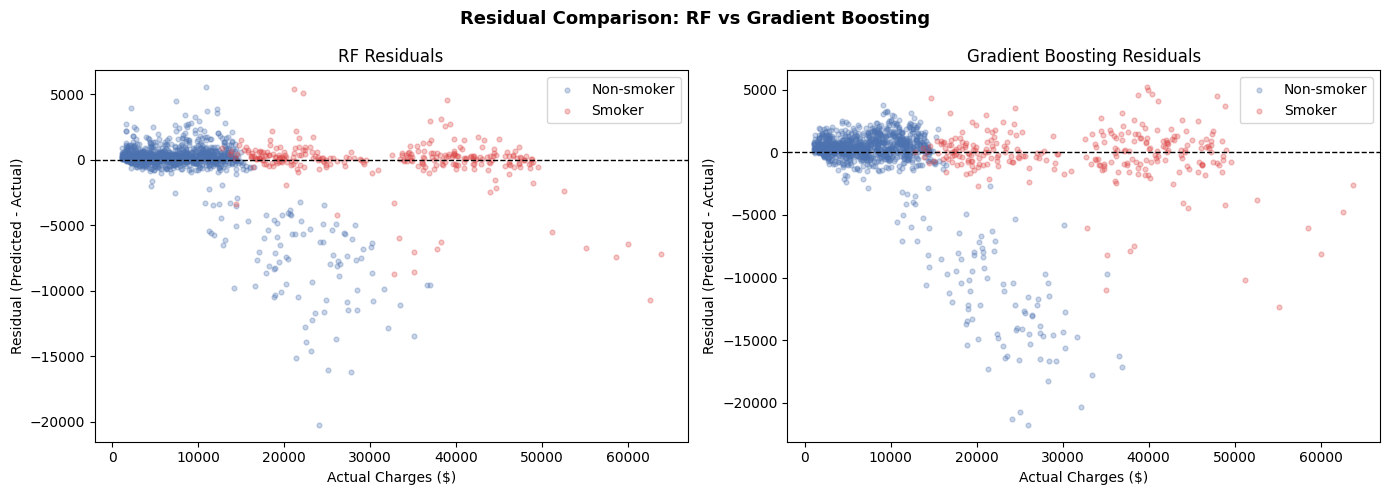

In [ ]:
# Tried gradient boosting, didn't do much for me.

High-cost threshold (95th percentile): $41,182
High-cost patients: 67 of 1338

Model 1: High-Cost Classifier (AUC)
Fold AUC scores: [0.997 0.999 0.984 0.999 0.994]
Mean AUC:        0.995
Std AUC:         0.006

Model 2: High-Cost Regressor (R²)
Fold R² scores:  [ 0.605  0.199 -0.644 -2.332 -0.38 ]
Mean R²:         -0.510
Std R²:          1.010


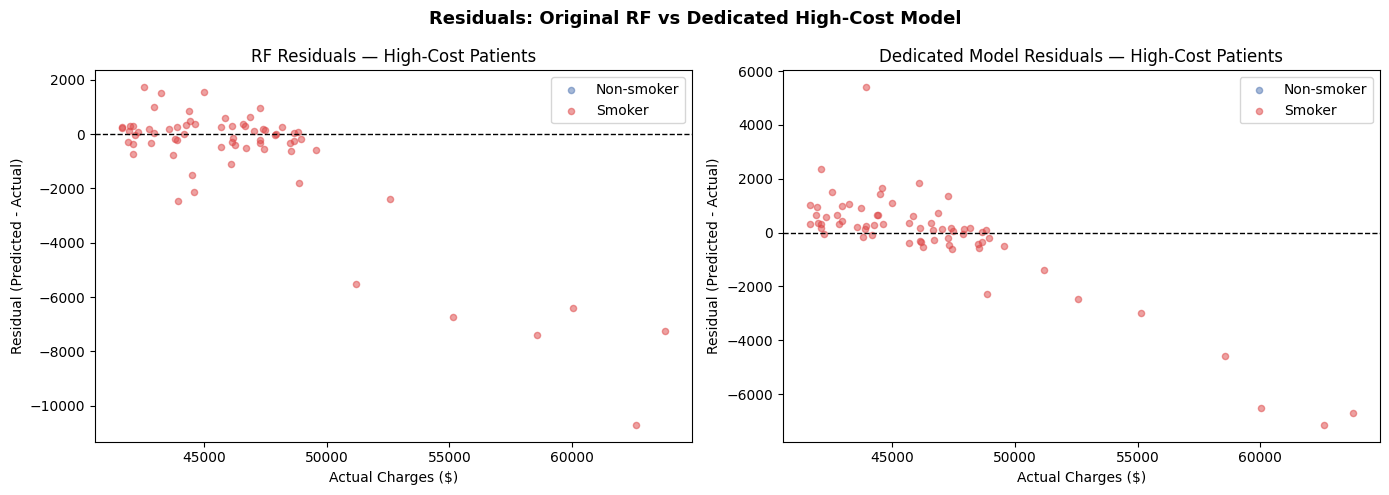

In [ ]:
# Again, no success here with high percentile analysis. Sample too small.

Low threshold (50th):  $9,382
High threshold (80th): $20,261

Bucket counts:
cost_bucket
0    669
1    401
2    268
Name: count, dtype: int64
  0 = Low, 1 = Medium, 2 = High

Ordinal Bucket Classifier (F1 Macro)
Fold F1 scores:  [0.831 0.794 0.84  0.832 0.821]
Mean F1:         0.823
Std F1:          0.016


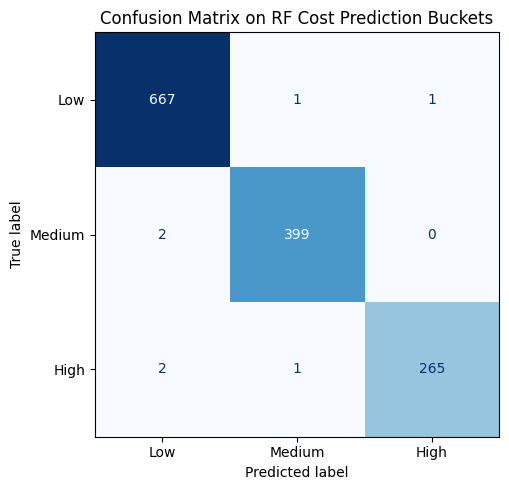


Patients above 80th percentile: 268

Lowered Threshold Regressor (R²)
Fold R² scores:  [0.768 0.778 0.69  0.828 0.787]
Mean R²:         0.770
Std R²:          0.045


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ordinal cost buckets
low      = df["charges"].quantile(0.50)
high     = df["charges"].quantile(0.80)

print(f"Low threshold (50th):  ${low:,.0f}")
print(f"High threshold (80th): ${high:,.0f}")

def assign_bucket(charge):
    if charge < low:
        return 0   # low
    elif charge < high:
        return 1   # medium
    else:
        return 2   # high

df["cost_bucket"] = df["charges"].apply(assign_bucket)
print(f"\nBucket counts:\n{df['cost_bucket'].value_counts().sort_index()}")
print(f"  0 = Low, 1 = Medium, 2 = High")

# Classifier on buckets
clf_bucket = RandomForestClassifier(n_estimators=75, random_state=42)
bucket_cv  = cross_val_score(clf_bucket, X, df["cost_bucket"], cv=5, scoring="f1_macro")

print("\n" + "=" * 45)
print("Ordinal Bucket Classifier (F1 Macro)")
print("=" * 45)
print(f"Fold F1 scores:  {bucket_cv.round(3)}")
print(f"Mean F1:         {bucket_cv.mean():.3f}")
print(f"Std F1:          {bucket_cv.std():.3f}")

# Confusion matrix
clf_bucket.fit(X, df["cost_bucket"])
preds = clf_bucket.predict(X)

cm = confusion_matrix(df["cost_bucket"], preds)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Low", "Medium", "High"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix on RF Cost Prediction Buckets")
plt.tight_layout()
plt.show()

# Lowered threshold regressor (80th percentile)
high_mask  = df["charges"] >= high
X_high80   = X[high_mask]
y_high80   = df.loc[high_mask, "log_charges"]

print(f"\nPatients above 80th percentile: {high_mask.sum()}")

reg_80 = RandomForestRegressor(n_estimators=200, random_state=42)
reg_80_cv = cross_val_score(reg_80, X_high80, y_high80, cv=5, scoring="r2")

print("\n" + "=" * 45)
print("Lowered Threshold Regressor (R²)")
print("=" * 45)
print(f"Fold R² scores:  {reg_80_cv.round(3)}")
print(f"Mean R²:         {reg_80_cv.mean():.3f}")
print(f"Std R²:          {reg_80_cv.std():.3f}")

We can accurately predict price ranges, but not the exact cost. This is the best result for predicting extremes so far, but sadly I've yet to find something that predicts them more accurately...